In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import os
import shutil
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pickle

In [2]:
directory_path = "datasets"
os.makedirs(directory_path, exist_ok=True)
download_path = kagglehub.dataset_download("ananthr1/weather-prediction")

for file in os.listdir(download_path):
    src_file = os.path.join(download_path, file)
    dst_file = os.path.join(directory_path, file)
    shutil.copy2(src_file, dst_file)

path = directory_path

100%|██████████| 11.5k/11.5k [00:00<?, ?B/s]

Extracting files...


In [81]:
df = pd.read_csv(os.path.join(path, "seattle-weather.csv"))
df

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain
...,...,...,...,...,...,...
1456,2015-12-27,8.6,4.4,1.7,2.9,rain
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [60]:
X = df[['precipitation', 'temp_max', 'temp_min', 'wind']]
y = df['weather']

In [61]:
scaller = StandardScaler()
X = scaller.fit_transform(X)

le = LabelEncoder()
y = le.fit_transform(y)

In [73]:
# count occurrences for each encoded class in y and show original class names
counts = pd.Series(y).value_counts().sort_index()
counts.index = le.classes_
print(counts)

drizzle     53
fog        101
rain       641
snow        26
sun        640
Name: count, dtype: int64


In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
model = SVC(kernel='rbf', random_state=42)
model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [67]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.757679180887372
Classification Report:
              precision    recall  f1-score   support

     drizzle       0.00      0.00      0.00         9
         fog       0.00      0.00      0.00        25
        rain       0.87      0.82      0.85       120
        snow       0.00      0.00      0.00         8
         sun       0.69      0.94      0.79       131

    accuracy                           0.76       293
   macro avg       0.31      0.35      0.33       293
weighted avg       0.66      0.76      0.70       293



d:\BeData\SMK Telkom\Project Analisis Data\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\BeData\SMK Telkom\Project Analisis Data\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\BeData\SMK Telkom\Project Analisis Data\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

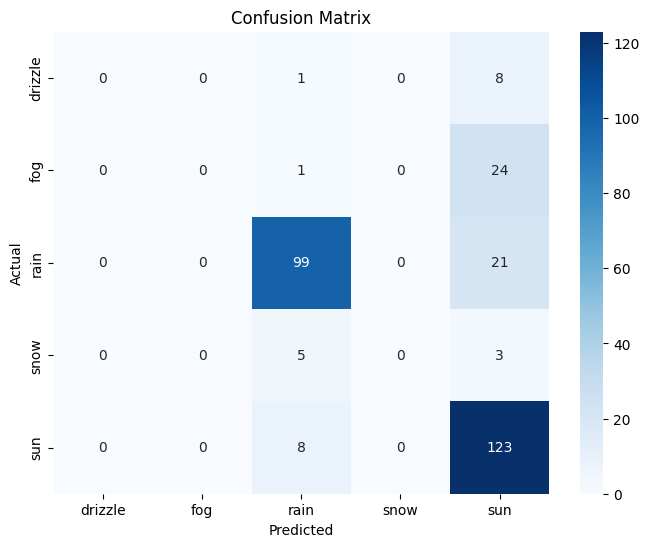

In [68]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [70]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy}")
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred, target_names=le.classes_))

Random Forest Accuracy: 0.8191126279863481
Random Forest Classification Report:
              precision    recall  f1-score   support

     drizzle       0.20      0.11      0.14         9
         fog       0.50      0.12      0.19        25
        rain       0.93      0.92      0.92       120
        snow       0.40      0.25      0.31         8
         sun       0.78      0.95      0.86       131

    accuracy                           0.82       293
   macro avg       0.56      0.47      0.48       293
weighted avg       0.79      0.82      0.79       293



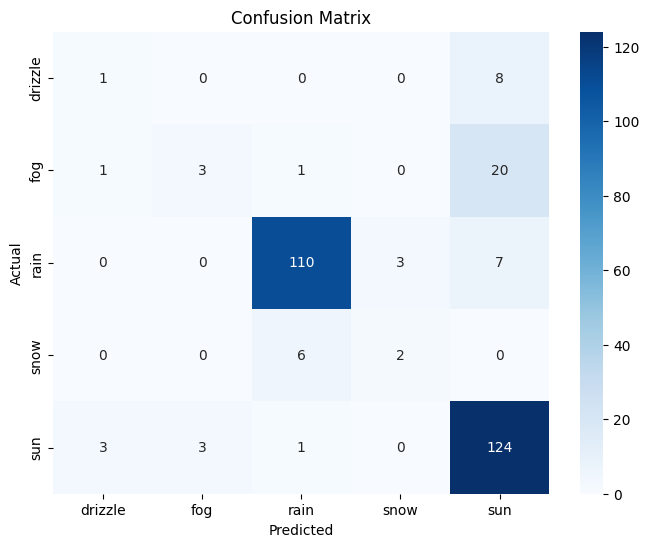

In [71]:
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [75]:
xgb_model = XGBClassifier(objective='multi:softmax', num_class=len(le.classes_), random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_pred)
print(f"XGBoost Accuracy: {xgb_accuracy}")
print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_pred, target_names=le.classes_))

XGBoost Accuracy: 0.7986348122866894
XGBoost Classification Report:
              precision    recall  f1-score   support

     drizzle       0.17      0.11      0.13         9
         fog       0.45      0.20      0.28        25
        rain       0.91      0.91      0.91       120
        snow       0.33      0.25      0.29         8
         sun       0.78      0.89      0.83       131

    accuracy                           0.80       293
   macro avg       0.53      0.47      0.49       293
weighted avg       0.77      0.80      0.78       293



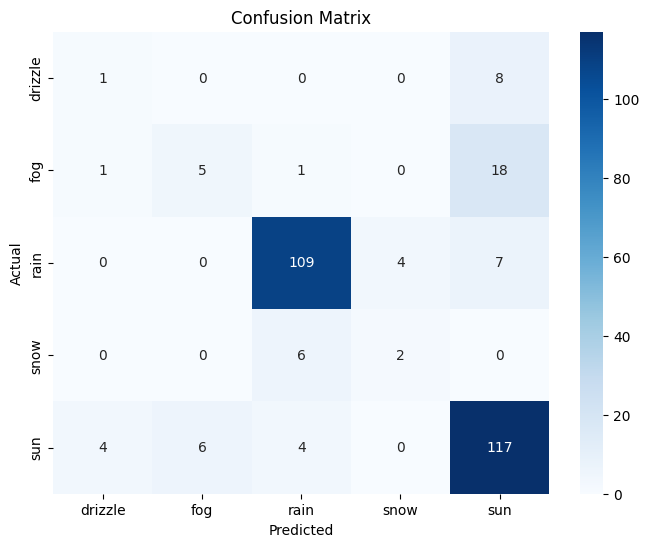

In [76]:
cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [78]:
with open('models/random-forest-model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

In [79]:
with open('models/label-encoder.pkl', 'wb') as f:
    pickle.dump(le, f)